# FIR Filter: Scipy Library vs RV32IMP DUT
Dự án: RV32IM P-Extension DSP Implementation

Notebook này thực hiện:
1. **Tải Dataset**: Lấy dữ liệu ECG từ Kaggle.
2. **Reference Models**: 
   - `Scipy Golden`: Dùng `lfilter` float (lý tưởng).
   - `Integer Ref`: Dùng `np.convolve` với hệ số Q7 + dịch bít giống C code.
3. **So sánh Multi-way**: Integer Ref vs Scala DUT vs P-Ext DUT.

**Cấu hình hiện tại**: Đã tăng dung lượng Input lên tối đa 1024 mẫu.

c:\Users\trsng\.venvs\rv32imp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 40 samples.


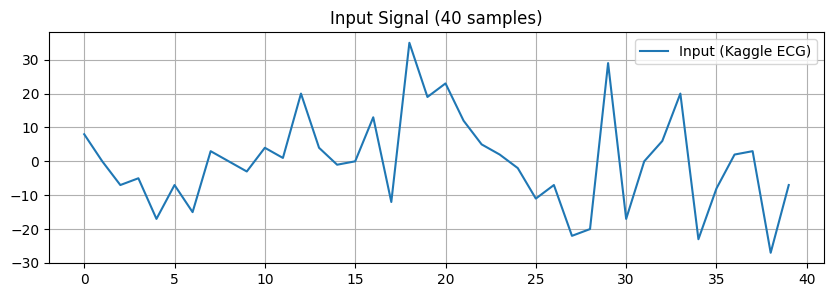

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
import kagglehub
import os

# --- 1. Tải và Load Dataset ---
print("Downloading dataset...")
path = kagglehub.dataset_download("apithm/ecg-and-eeg-stress-features")

ecg_file = [os.path.join(path, f) for f in os.listdir(path) if 'ECG' in f and f.endswith('.xlsx')][0]
df = pd.read_excel(ecg_file, sheet_name='AC1')

# Tăng lên 1024 mẫu (hoặc lấy hết nếu dataset nhỏ hơn)
max_samples = 1024
raw_input = df['Mean HR (bpm)'].values[:max_samples]
input_centered = raw_input - np.mean(raw_input)
input_int8 = np.clip(input_centered, -128, 127).astype(np.int8)

print(f"Loaded {len(input_int8)} samples.")

plt.figure(figsize=(10, 3))
plt.plot(input_int8, label='Input (Kaggle ECG)')
plt.title(f"Input Signal ({len(input_int8)} samples)")
plt.legend(); plt.grid(True); plt.show()

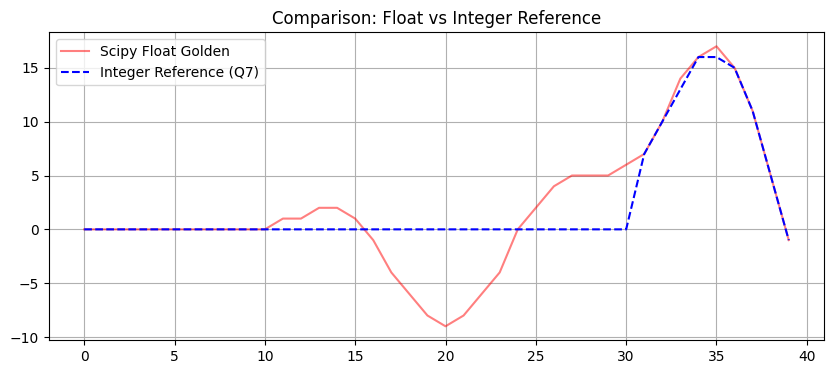

In [2]:
# --- 2. Reference Models ---
TAPS = 32
SCALE = 128       
SCALE_SHIFT = 7   

h_float = signal.firwin(TAPS, cutoff=10, fs=100, window='hamming')
h_q7 = np.round(h_float * SCALE).astype(np.int32)

scipy_golden = signal.lfilter(h_float, 1.0, input_int8)
scipy_golden_int8 = np.clip(np.round(scipy_golden), -128, 127).astype(np.int8)

raw_mac = np.convolve(input_int8, h_q7, mode='full')[:len(input_int8)]
integer_ref = np.clip(
    (raw_mac + (1 << (SCALE_SHIFT - 1))) >> SCALE_SHIFT, -128, 127
).astype(np.int8)
integer_ref[:TAPS-1] = 0  

plt.figure(figsize=(10, 4))
plt.plot(scipy_golden_int8, 'r-', alpha=0.5, label='Scipy Float Golden')
plt.plot(integer_ref, 'b--', label='Integer Reference (Q7)')
plt.title("Comparison: Float vs Integer Reference")
plt.legend(); plt.grid(True); plt.show()

Max error: 1
Mean error: 0.05


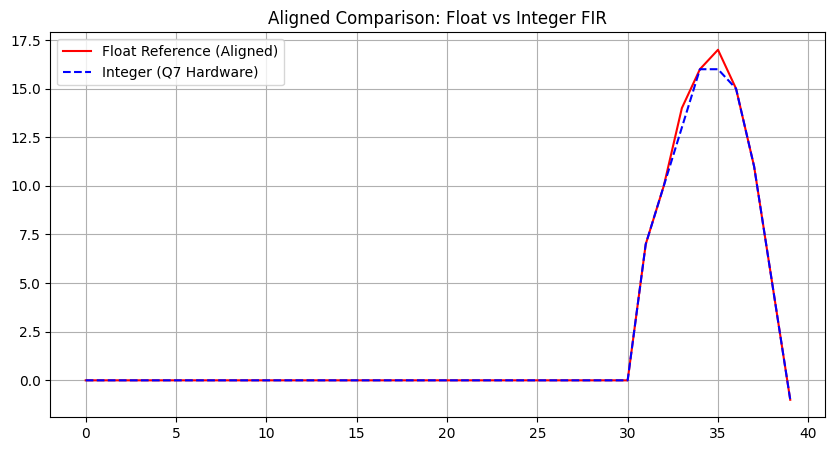

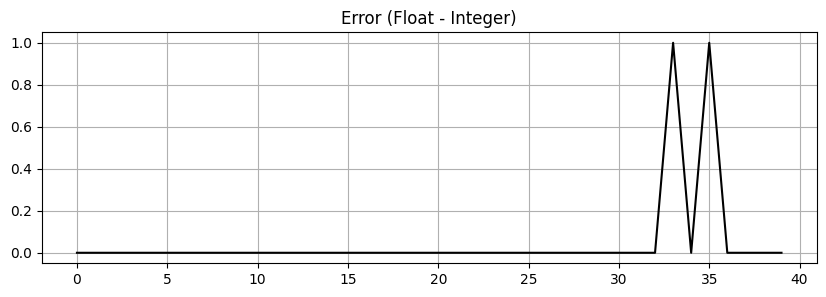

In [5]:
# --- 2. Reference Models (Optimized) ---
TAPS = 32
SCALE = 128
SHIFT = 7

# 1. Design filter
h_float = signal.firwin(TAPS, cutoff=10, fs=100, window='hamming')
h_q7 = np.round(h_float * SCALE).astype(np.int32)

# 2. Float reference
scipy_float = signal.lfilter(h_float, 1.0, input_int8)
scipy_int8 = np.clip(np.round(scipy_float), -128, 127).astype(np.int8)

# 3. Integer FIR (hardware-like)
raw_mac = np.convolve(input_int8, h_q7, mode='full')[:len(input_int8)]

integer_ref = np.clip(
    (raw_mac + (1 << (SHIFT - 1))) >> SHIFT,
    -128, 127
).astype(np.int8)

# 4. Align delay (QUAN TRỌNG)
delay = TAPS - 1

scipy_aligned = scipy_int8.copy()
integer_aligned = integer_ref.copy()

scipy_aligned[:delay] = 0
integer_aligned[:delay] = 0

# 5. Compute error
error = scipy_aligned.astype(np.int16) - integer_aligned.astype(np.int16)

print("Max error:", np.max(np.abs(error)))
print("Mean error:", np.mean(np.abs(error)))

# 6. Plot
plt.figure(figsize=(10,5))
plt.plot(scipy_aligned, 'r-', label='Float Reference (Aligned)')
plt.plot(integer_aligned, 'b--', label='Integer (Q7 Hardware)')
plt.title("Aligned Comparison: Float vs Integer FIR")
plt.legend(); plt.grid(True)
plt.show()

# 7. Error plot (rất quan trọng)
plt.figure(figsize=(10,3))
plt.plot(error, 'k-')
plt.title("Error (Float - Integer)")
plt.grid(True)
plt.show()

In [3]:
# --- 3. Export Data ---
def save_as_hex_word(data_array, filename):
    flat_data = data_array.flatten().astype(np.uint8)
    padding = (4 - len(flat_data) % 4) % 4
    if padding > 0: flat_data = np.pad(flat_data, (0, padding), mode='constant')
    with open(filename, 'w') as f:
        for i in range(0, len(flat_data), 4):
            p = [int(x) for x in flat_data[i:i+4]]
            word = (p[3] << 24) | (p[2] << 16) | (p[1] << 8) | p[0]
            f.write(f"{word:08x}\n")
    print(f"Exported {filename}")

def save_c_header(input_arr, h_arr, scale_shift, filename):
    with open(filename, 'w') as f:
        f.write("#ifndef __FIR_DATA_H\n#define __FIR_DATA_H\n\n")
        f.write("#include <stdint.h>\n\n")
        f.write(f"#define FIR_TAPS {len(h_arr)}\n")
        f.write(f"#define INPUT_LEN {len(input_arr)}\n")
        f.write(f"#define SCALE_SHIFT {scale_shift}\n\n")
        f.write("static const int8_t fir_coeffs[FIR_TAPS] = { " + ", ".join(map(str, h_arr)) + " };\n")
        f.write("static const int8_t input_data[INPUT_LEN] = { " + ", ".join(map(str, input_arr)) + " };\n")
        f.write("\n#endif\n")
    print(f"Exported {filename}")

save_as_hex_word(input_int8, 'input.hex')
save_as_hex_word(integer_ref, 'golden.hex')
save_c_header(input_int8, h_q7, SCALE_SHIFT, 'fir_data.h')

Exported input.hex
Exported golden.hex
Exported fir_data.h


## 4. So sánh Library vs Scala DUT vs P-Ext DUT

Total Absolute Error (Scala): 0
Total Absolute Error (P-Ext): 0


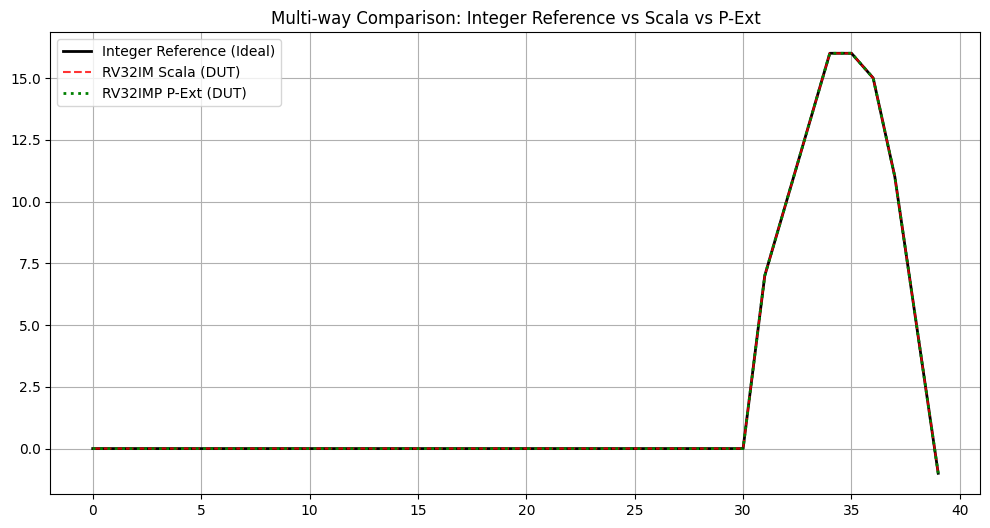

In [4]:
def load_signature(path, target_len):
    if not os.path.exists(path):
        return None
    words = []
    with open(path, 'r') as f: 
        for l in f: words.append(int(l.strip(), 16))
    bytes_raw = []
    for w in words: 
        for i in range(4): bytes_raw.append((w >> (i*8)) & 0xFF)
    return np.array(bytes_raw[:target_len], dtype=np.uint8).astype(np.int8)

scala_res = load_signature('../../sw/Filter-Fir/scala_signature.hex', len(integer_ref))
pext_res = load_signature('../../sw/Filter-Fir/pext_signature.hex', len(integer_ref))

plt.figure(figsize=(12, 6))
plt.plot(integer_ref, 'k-', linewidth=2, label='Integer Reference (Ideal)')

if scala_res is not None:
    plt.plot(scala_res, 'r--', alpha=0.8, label='RV32IM Scala (DUT)')
    err = np.sum(np.abs(integer_ref.astype(int) - scala_res.astype(int)))
    print(f"Total Absolute Error (Scala): {err}")

if pext_res is not None:
    plt.plot(pext_res, 'g:', linewidth=2, label='RV32IMP P-Ext (DUT)')
    err = np.sum(np.abs(integer_ref.astype(int) - pext_res.astype(int)))
    print(f"Total Absolute Error (P-Ext): {err}")

plt.title("Multi-way Comparison: Integer Reference vs Scala vs P-Ext")
plt.legend(); plt.grid(True); plt.show()